In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Using device: cpu
Found 99 images


Creating masks: 100%|██████████| 99/99 [00:26<00:00,  3.67it/s]


Train: 79 Val: 20
Epoch 1/50  Train:0.6581  Val:0.6406
Saved best model
Epoch 2/50  Train:0.5574  Val:0.7751
Epoch 3/50  Train:0.5179  Val:0.5938
Saved best model
Epoch 4/50  Train:0.4893  Val:0.5615
Saved best model
Epoch 5/50  Train:0.4674  Val:0.5013
Saved best model
Epoch 6/50  Train:0.4431  Val:0.5335
Epoch 7/50  Train:0.4385  Val:0.5459
Epoch 8/50  Train:0.4207  Val:0.4668
Saved best model
Epoch 9/50  Train:0.4075  Val:0.4865
Epoch 10/50  Train:0.4012  Val:0.4678
Epoch 11/50  Train:0.3845  Val:0.5200
Epoch 12/50  Train:0.3681  Val:0.4540
Saved best model
Epoch 13/50  Train:0.3688  Val:0.4650
Epoch 14/50  Train:0.3450  Val:0.4351
Saved best model
Epoch 15/50  Train:0.3377  Val:0.4466
Epoch 16/50  Train:0.3237  Val:0.5232
Epoch 17/50  Train:0.3027  Val:0.4376
Epoch 18/50  Train:0.3016  Val:0.4922
Epoch 19/50  Train:0.2915  Val:0.4309
Saved best model
Epoch 20/50  Train:0.2792  Val:0.4214
Saved best model
Epoch 21/50  Train:0.2726  Val:0.4565
Epoch 22/50  Train:0.2650  Val:0.4235
Ep

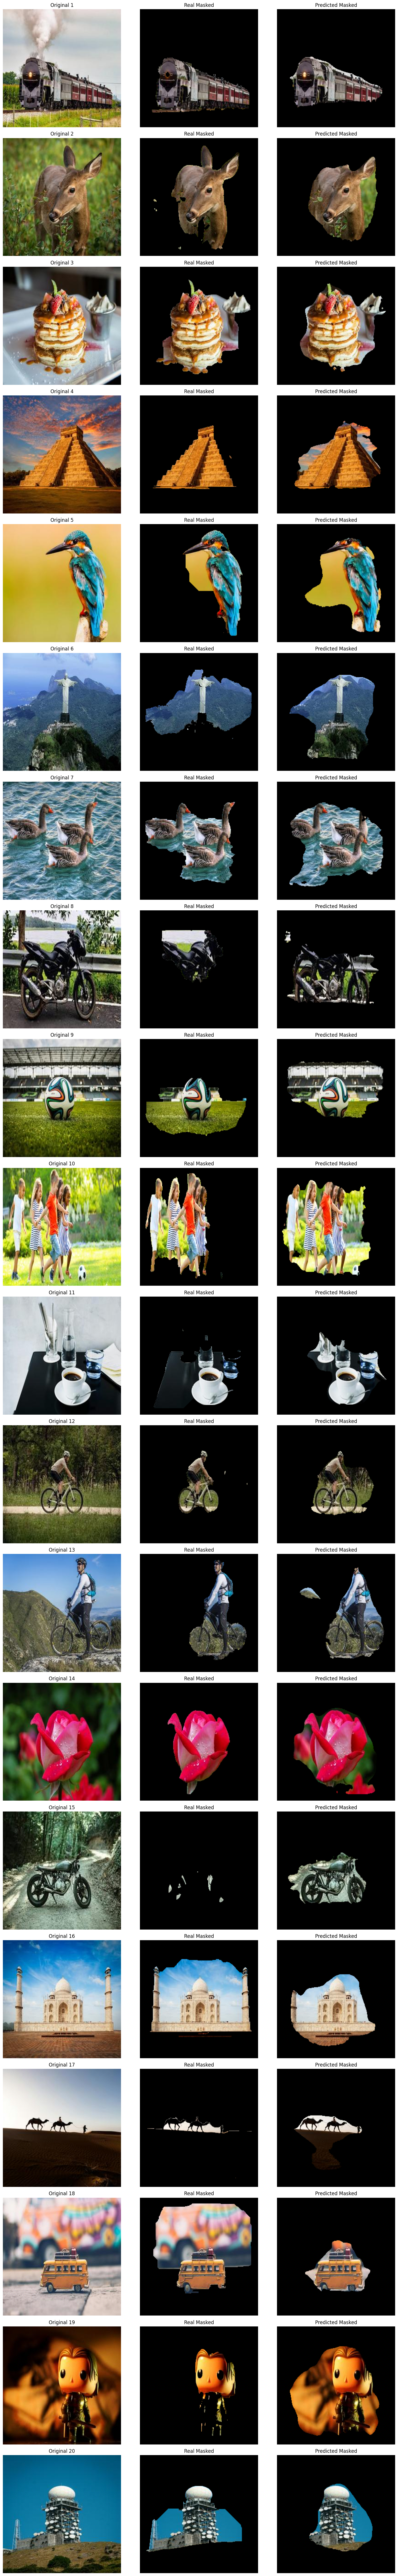

Done.


In [2]:
import os
import random
from glob import glob
from tqdm import tqdm
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from torchmetrics import Accuracy
import time

# ======================
# 1. PATHS + SETTINGS
# ======================
INPUT_DIR = '/kaggle/input/model-images'
PROC_DIR = '/kaggle/working/processed_images'
MASK_DIR = '/kaggle/working/binary_masks'
MODEL_DIR = '/kaggle/working/models'

os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE = 256
BATCH_SIZE = 4
NUM_EPOCHS = 50
LR = 5e-4
PLOT_SAMPLES = 20
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# ============================
# 2. GRABCUT MASK GENERATION
# ============================
def make_grabcut_mask(rgb_image, iter_count=15):
    img = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2BGR)
    h, w = img.shape[:2]
    rect = (int(w*0.05), int(h*0.05), int(w*0.9), int(h*0.9))

    mask = np.zeros((h, w), np.uint8)
    bgd = np.zeros((1, 65), np.float64)
    fgd = np.zeros((1, 65), np.float64)

    try:
        cv2.grabCut(img, mask, rect, bgd, fgd, iter_count, cv2.GC_INIT_WITH_RECT)
    except:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, th = cv2.threshold(gray, 120, 1, cv2.THRESH_BINARY)
        return th

    mask2 = np.where((mask == 1) | (mask == 3), 1, 0).astype('uint8')
    return mask2


# PROCESS INPUT IMAGES
img_paths = [p for p in glob(os.path.join(INPUT_DIR, '*')) if p.lower().endswith(('.png','.jpg','.jpeg','.webp'))]
print("Found", len(img_paths), "images")

processed_images = []
for p in tqdm(img_paths, desc="Creating masks"):
    name = os.path.splitext(os.path.basename(p))[0]
    out_img = os.path.join(PROC_DIR, name + '.jpg')
    out_mask = os.path.join(MASK_DIR, name + '.png')

    img = Image.open(p).convert('RGB')
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    img_np = np.array(img)

    Image.fromarray(img_np).save(out_img)

    if not os.path.exists(out_mask):
        m = make_grabcut_mask(img_np)
        m = (m * 255).astype('uint8')
        Image.fromarray(m).save(out_mask)

    processed_images.append((out_img, out_mask))


# ======================
# 3. DATASET
# ======================
transform_train = transforms.Compose([
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])


class SegmentationDataset(Dataset):
    def __init__(self, items, tform):
        self.items = items
        self.tform = tform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, mask_path = self.items[idx]
        img = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')

        img = self.tform(img)

        mask = transforms.ToTensor()(mask)
        mask = (mask > 0.5).float()

        return img, mask


random.shuffle(processed_images)
split = int(0.8 * len(processed_images))

train_ds = SegmentationDataset(processed_images[:split], transform_train)
val_ds = SegmentationDataset(processed_images[split:], transform_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Train:", len(train_ds), "Val:", len(val_ds))


# ======================
# 4. DEEPER U-NET
# ======================
def conv_block(ch_in, ch_out):
    return nn.Sequential(
        nn.Conv2d(ch_in, ch_out, 3, padding=1),
        nn.BatchNorm2d(ch_out),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch_out, ch_out, 3, padding=1),
        nn.BatchNorm2d(ch_out),
        nn.ReLU(inplace=True),
    )


class DeepUNet(nn.Module):
    def __init__(self):
        super().__init__()

        features = [32, 64, 128, 256, 512]

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        self.pool = nn.MaxPool2d(2)

        in_c = 3
        # DOWN
        for f in features:
            self.downs.append(conv_block(in_c, f))
            in_c = f

        # BOTTLENECK
        self.bottleneck = conv_block(features[-1], features[-1]*2)

        # UP
        rev = features[::-1]
        in_up = features[-1]*2
        for f in rev:
            self.ups.append(
                nn.ModuleList([
                    nn.ConvTranspose2d(in_up, f, 2, 2),
                    conv_block(f*2, f)
                ])
            )
            in_up = f

        self.final = nn.Conv2d(features[0], 1, 1)

    def forward(self, x):
        skips = []
        out = x

        # ENCODER
        for d in self.downs:
            out = d(out)
            skips.append(out)
            out = self.pool(out)

        # BOTTLENECK
        out = self.bottleneck(out)
        skips = skips[::-1]

        # DECODER
        for idx, (up, conv) in enumerate(self.ups):
            out = up(out)
            sc = skips[idx]

            if out.shape[2:] != sc.shape[2:]:
                out = F.interpolate(out, sc.shape[2:], mode='bilinear', align_corners=False)

            out = torch.cat([sc, out], dim=1)
            out = conv(out)

        return self.final(out)


model = DeepUNet().to(DEVICE)


# ======================
# 5. LOSS + OPTIMIZER
# ======================
class DiceLoss(nn.Module):
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)
        inter = (pred * target).sum()
        return 1 - ((2 * inter) / (pred.sum() + target.sum() + 1e-6))


bce = nn.BCEWithLogitsLoss()
dice = DiceLoss()


def loss_fn(p, t):
    return 0.5 * bce(p,t) + 0.5 * dice(p,t)


optim = torch.optim.Adam(model.parameters(), lr=LR)


# ======================
# 6. TRAINING
# ======================
def train_epoch():
    model.train()
    tot = 0
    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        pred = model(x)
        loss = loss_fn(pred, y)

        optim.zero_grad()
        loss.backward()
        optim.step()
        tot += loss.item() * x.size(0)

    return tot / len(train_ds)


def val_epoch():
    model.eval()
    tot = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            pred = model(x)
            loss = loss_fn(pred, y)
            tot += loss.item() * x.size(0)
    return tot / len(val_ds)


best = 1e9
for ep in range(1, NUM_EPOCHS + 1):
    tl = train_epoch()
    vl = val_epoch()
    print(f"Epoch {ep}/{NUM_EPOCHS}  Train:{tl:.4f}  Val:{vl:.4f}")

    if vl < best:
        best = vl
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, "best.pth"))
        print("Saved best model")


# ======================
# 7. LOAD BEST & METRICS
# ======================
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best.pth"), map_location=DEVICE))
model.eval()

acc = Accuracy(task="binary", threshold=0.5).to(DEVICE)

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        pr = torch.sigmoid(model(x))
        acc.update(pr, y)

print("\nValidation Accuracy:", float(acc.compute()))
acc.reset()


# ======================
# 8. VISUALIZATION (UPDATED)
# ======================
samples = processed_images[split : split + PLOT_SAMPLES]

transform_infer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

rows = len(samples)
plt.figure(figsize=(15, 4.5 * rows))

for i, (img_path, mask_path) in enumerate(samples):
    img = Image.open(img_path).convert('RGB')
    m = Image.open(mask_path).convert('L')

    img_np = np.array(img)
    real_mask = (np.array(m) / 255.0).astype(np.uint8)

    inp = transform_infer(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = torch.sigmoid(model(inp))[0,0].cpu().numpy()

    pred_bin = (pred > 0.5).astype(np.uint8)

    real_rgb = img_np * np.expand_dims(real_mask, -1)
    pred_rgb = img_np * np.expand_dims(pred_bin, -1)

    idx = i * 3 + 1
    # Original
    plt.subplot(rows,3,idx)
    plt.imshow(img_np)
    plt.title(f"Original {i+1}")
    plt.axis('off')

    # Real masked
    plt.subplot(rows,3,idx+1)
    plt.imshow(real_rgb)
    plt.title("Real Masked")
    plt.axis('off')

    # Pred masked
    plt.subplot(rows,3,idx+2)
    plt.imshow(pred_rgb)
    plt.title("Predicted Masked")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Done.")
